# Limpieza de datos

In [19]:
import pandas as pd

df = pd.read_csv("25161_GVE01_08052026.csv") # con read_csv asigno la ruta del archivo a un objeto para poder manejarlo
df.head()

,fecha,precip,evap,tmax,tmin
0,1970-01-01,0,2.25,26.5,7
1,1970-01-02,0,5.14,27,9
2,1970-01-03,1.9,1.19,20,13.5
3,1970-01-04,15.3,0.78,17.5,14.5
4,1970-01-05,0,1.73,25,13.5


In [20]:
def limpieza(df):
    df.replace("NULO", pd.NA, inplace=True) # todos las celdas con el string "Nulo", los transforma en NaN(osea datos nulos)

    columnas = ["precip", "evap", "tmax", "tmin"]

    for columna in columnas:
        df[columna] = pd.to_numeric(df[columna], errors="coerce") # las celdas "precip", "evap", "tmax", "tmin" las transformo a tipo numerico

    df["fecha"] = pd.to_datetime(df["fecha"], format="%Y-%m-%d") # las celdas de la columna fecha van a ser datetime 
    return df

In [21]:
df=limpieza(df)
df.head()

,fecha,precip,evap,tmax,tmin
0,1970-01-01,0.0,2.25,26.5,7.0
1,1970-01-02,0.0,5.14,27.0,9.0
2,1970-01-03,1.9,1.19,20.0,13.5
3,1970-01-04,15.3,0.78,17.5,14.5
4,1970-01-05,0.0,1.73,25.0,13.5


In [22]:
df.dtypes

fecha     datetime64[us]
precip           float64
evap             float64
tmax             float64
tmin             float64
dtype: object

In [23]:
def verificar_si_hay_nulo(df):
    
    sumnulo0 = df["fecha"].isnull().sum() # creo un objeto el cual contiene el numero de nulos de la columna fecha
    sumnulo1 = df["precip"].isnull().sum() # creo un objeto el cual contiene el numero de nulos de la columna precip
    sumnulo2 = df["evap"].isnull().sum() # creo un objeto el cual contiene el numero de nulos de la columna evap
    sumnulo3 = df["tmax"].isnull().sum() # creo un objeto el cual contiene el numero de nulos de la columna tmax
    sumnulo4 = df["tmin"].isnull().sum() # creo un objeto el cual contiene el numero de nulos de la columna tmin

    # retorno un print para mostrar el numero de nulos de cada columna
    return print(f"Nulos de fecha: {sumnulo0}, Nulos de precip: {sumnulo1}, Nulos de evap: {sumnulo2}, Nulos de tmax: {sumnulo3}, Nulos de tmin: {sumnulo4}")

In [24]:
verificar_si_hay_nulo(df)

Nulos de fecha: 0, Nulos de precip: 44, Nulos de evap: 2509, Nulos de tmax: 118, Nulos de tmin: 118


In [25]:
def mediadenulos(df):
    
    columnas = ["precip","evap","tmax","tmin"] # creo una lista con el nombre de las columnas
    for columna in columnas: # recorro las columnas
        media = df[columna].mean() # saco la media de la columna que le toca en la iteracion
        df[columna] = df[columna].fillna(media)#a la columna de la iteracion con el fillna() sustituyo todos los valores nulos por la media
        print(f"media de {columna}: {media}") # imprimo la media de cada columna
    return df

In [26]:
df=mediadenulos(df)
df.head(20)

media de precip: 1.231326830908938
media de evap: 4.8501972846839205
media de tmax: 33.02697351721804
media de tmin: 18.55095185717912


,fecha,precip,evap,tmax,tmin
0,1970-01-01,0.0,2.25,26.5,7.0
1,1970-01-02,0.0,5.14,27.0,9.0
2,1970-01-03,1.9,1.19,20.0,13.5
3,1970-01-04,15.3,0.78,17.5,14.5
4,1970-01-05,0.0,1.73,25.0,13.5
5,1970-01-06,0.0,3.69,25.5,11.5
6,1970-01-07,0.0,1.46,25.0,11.0
7,1970-01-08,0.0,2.65,28.5,12.0
8,1970-01-09,0.0,1.33,29.0,13.5
9,1970-01-10,0.0,4.14,28.5,15.5


In [27]:
verificar_si_hay_nulo(df)

Nulos de fecha: 0, Nulos de precip: 0, Nulos de evap: 0, Nulos de tmax: 0, Nulos de tmin: 0


# Analisis y Exploracion de Datos Sensor Conagua
## Estación 25161 — El dorado, Culiacán, Sinaloa


 Este análisis tiene como objetivo estudiar el comportamiento climatológico
 de la ciudad de Culiacán, Sinaloa, a partir de los datos registrados por la
 estación 25161 perteneciente a la red de monitoreo de la Comisión
 Nacional del Agua (CONAGUA).

### 1. Análisis estadístico descriptivo 

In [36]:
def Analisis_Descriptivo():
    columnas = ["precip", "evap", "tmax", "tmin"]

    for columna in columnas:

        print("\n======================")
        print(f"COLUMNA: {columna}")
        print("======================")

        # media
        media = df[columna].mean()
        print("Media:", media)

        # mediana
        mediana = df[columna].median()
        print("Mediana:", mediana)

        # moda
        moda = df[columna].mode()[0]
        print("Moda:", moda)

        # minimo
        minimo = df[columna].min()
        print("Minimo:", minimo)

        # maximo
        maximo = df[columna].max()
        print("Maximo:", maximo)

        # rango
        rango = maximo - minimo
        print("Rango:", rango)

        # varianza
        varianza = df[columna].var()
        print("Varianza:", varianza)

        # desviacion estandar
        desviacion = df[columna].std()
        print("Desviacion estandar:", desviacion)

In [37]:
Analisis_Descriptivo()


COLUMNA: precip
Media: 1.231326830908938
Mediana: 0.0
Moda: 0.0
Minimo: 0.0
Maximo: 278.0
Rango: 278.0
Varianza: 62.76321181824801
Desviacion estandar: 7.922323637560385

COLUMNA: evap
Media: 4.8501972846839205
Mediana: 4.8501972846839205
Moda: 4.8501972846839205
Minimo: 0.07
Maximo: 13.6
Rango: 13.53
Varianza: 2.644392847943238
Desviacion estandar: 1.6261589245652586

COLUMNA: tmax
Media: 33.02697351721804
Mediana: 33.5
Moda: 35.0
Minimo: 17.5
Maximo: 42.5
Rango: 25.0
Varianza: 10.974726947278057
Desviacion estandar: 3.312812543335052

COLUMNA: tmin
Media: 18.55095185717912
Mediana: 18.0
Moda: 25.0
Minimo: 2.5
Maximo: 30.5
Rango: 28.0
Varianza: 31.811020173559545
Desviacion estandar: 5.640125900506082


### Interpretación del análisis descriptivo

**Desviación estándar:**
- `precip`: La desviación estándar  es alta, lo que indica que los valores de 
  precipitación diaria están muy dispersos respecto a la media. Esto pasa 
  porque la mayoría de los días no llueve, pero cuando llueve puede ser de forma 
  muy intensa.
- `evap`: La desviación estándar es moderada, lo que quiere decir que la evaporación 
  del día a día no varía demasiado de un día a otro.
- `tmax` y `tmin`: Las dos tienen una desviación estándar baja en comparación con 
  su rango, lo que quiere decir que las temperaturas son relativamente estables y no 
  presentan cambios bruscos del día a día.

**Comparación media vs mediana:**
- `precip`: La media es mayor que la mediana, lo que indica que la distribución 
  está sesgada a la derecha. Esto se debe a que hay días con lluvias muy intensas 
  que jalan la media hacia arriba.
- `evap`: La media y mediana son cercanas, lo que nos indica una distribución 
  algo simétrica.
- `tmax` y `tmin`: La media y mediana son muy cercanas, lo que indica que las 
  temperaturas siguen una distribución muy simétrica.

**Valores atípicos (outliers):**
- `precip`: Existen valores atípicos altos que se debe a días de lluvia 
  intensa, posiblemente asociados a tormentas tropicales o huracanes que afectan 
  la región de Sinaloa en verano y otoño.
- `evap`: Puede haber outliers en días de condiciones extremas de calor y viento.
- `tmax` y `tmin`: Los outliers son pocos y estos corresponden a días con temperaturas 
  raras que son altas o bajas, seguramente asociados a eventos climáticos atípicos.

### 2. Construcción de gráficas.

In [38]:
import matplotlib.pyplot as plt
import numpy as np


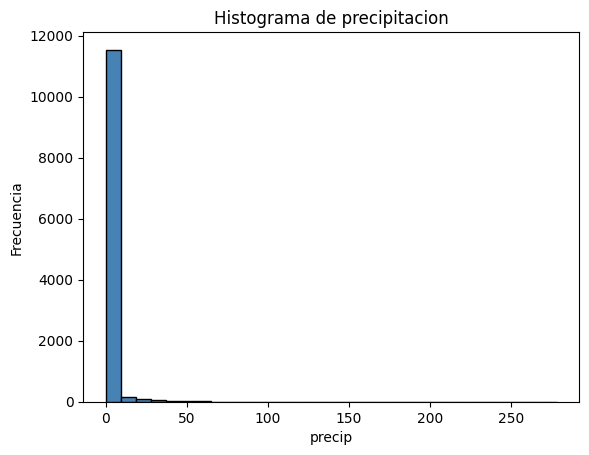

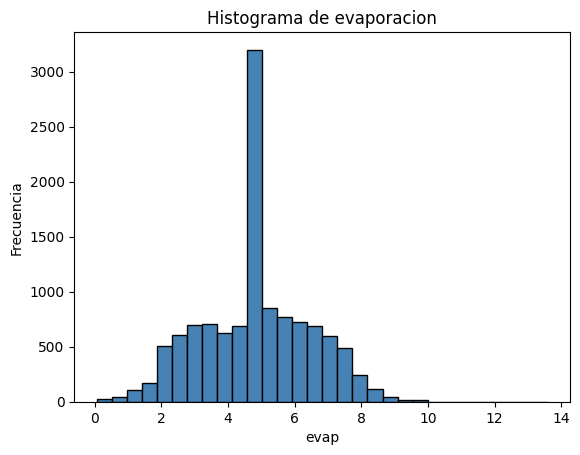

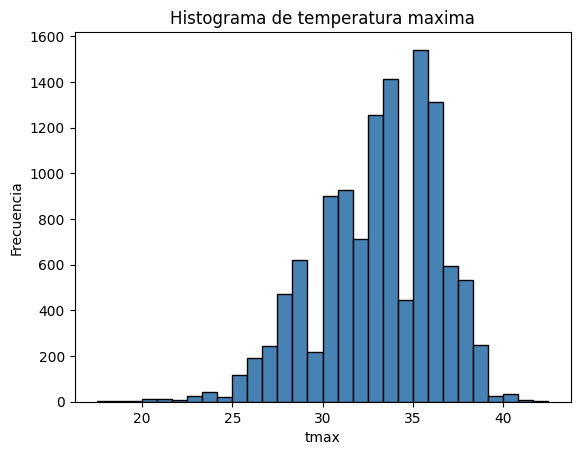

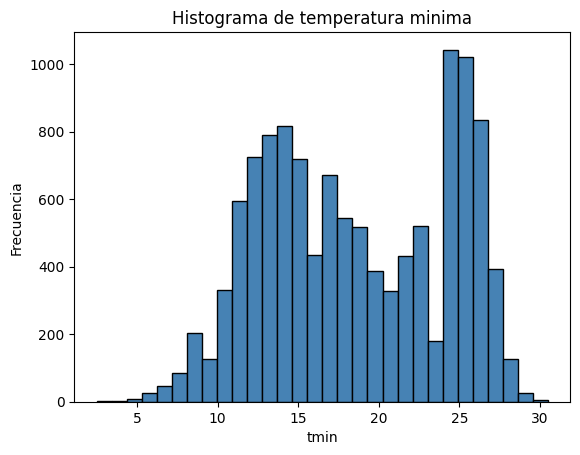

In [39]:
plt.figure()
plt.hist(df["precip"], bins=30, color="steelblue", edgecolor="black")
plt.title("Histograma de precipitacion")
plt.xlabel("precip")
plt.ylabel("Frecuencia")
plt.show()

plt.figure()
plt.hist(df["evap"], bins=30, color="steelblue", edgecolor="black")
plt.title("Histograma de evaporacion")
plt.xlabel("evap")
plt.ylabel("Frecuencia")
plt.show()

plt.figure()
plt.hist(df["tmax"], bins=30, color="steelblue", edgecolor="black")
plt.title("Histograma de temperatura maxima")
plt.xlabel("tmax")
plt.ylabel("Frecuencia")
plt.show()

plt.figure()
plt.hist(df["tmin"], bins=30, color="steelblue", edgecolor="black")
plt.title("Histograma de temperatura minima")
plt.xlabel("tmin")
plt.ylabel("Frecuencia")
plt.show()

### Análisis de los histogramas

**Precipitación:**
Como pudimos ver que la media es mayor que la mediana, podemos ahora ver que la 
distribución está muy sesgada a la derecha. La gran mayoría de los días
registran precipitación cercana a cero, mientras que una pequeña cantidad de días
tiene valores muy altos.

**Evaporación:**
La distribución es más simétrica que la grafica de la precipitación, tiene una forma 
acampanada que se concentra alrededor de la media. Esto es porque coincide con que la 
media y mediana son cercanas, esto indicando poca asimetría.

**Temperatura máxima:**
La distribución con picos irregulares, lo que refleja las
estaciones a lo largo del año. Los picos corresponden a las temperaturas
típicas del invierno y del verano. La media y mediana estan cerca lo que confirman 
que no hay un sesgo muy grande.

**Temperatura mínima:**
Similar a la temperatura máxima, presenta una distribución con picos irregulares por las
estaciones del año. Los valores se distribuyen de forma relativamente simétrica
alrededor de la media.

In [40]:
from scipy.stats import gaussian_kde

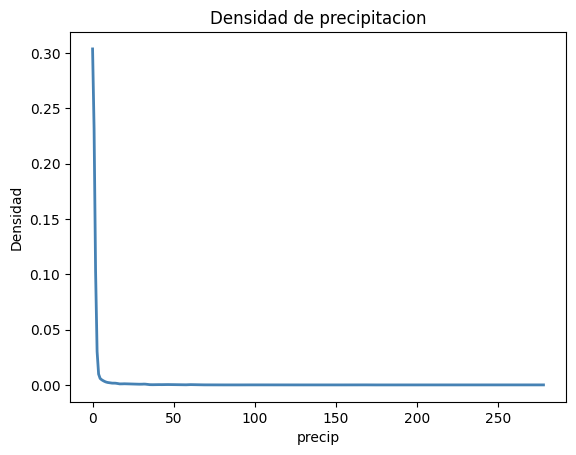

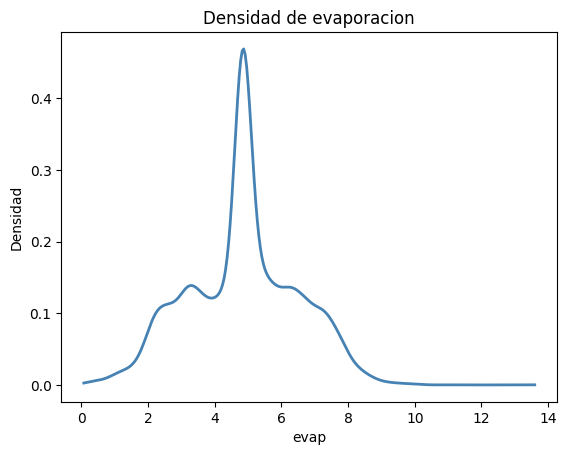

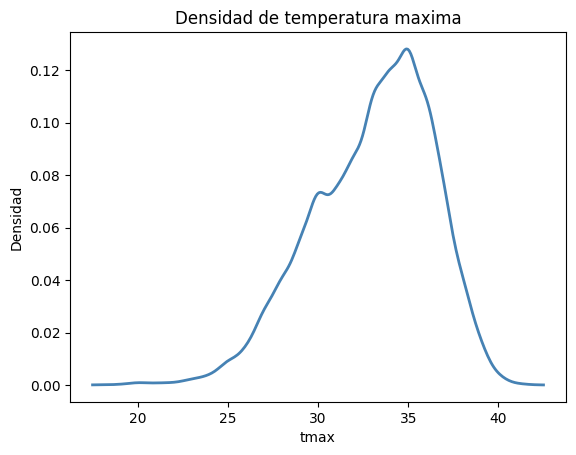

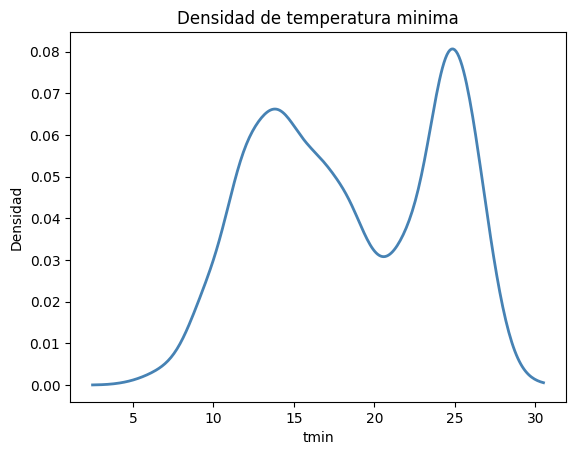

In [41]:
datos = df["precip"]
kde = gaussian_kde(datos)
x = np.linspace(datos.min(), datos.max(), 300)
plt.figure()
plt.plot(x, kde(x), color="steelblue", linewidth=2)
plt.title("Densidad de precipitacion")
plt.xlabel("precip")
plt.ylabel("Densidad")
plt.show()

datos = df["evap"]
kde = gaussian_kde(datos)
x = np.linspace(datos.min(), datos.max(), 300)
plt.figure()
plt.plot(x, kde(x), color="steelblue", linewidth=2)
plt.title("Densidad de evaporacion")
plt.xlabel("evap")
plt.ylabel("Densidad")
plt.show()

datos = df["tmax"]
kde = gaussian_kde(datos)
x = np.linspace(datos.min(), datos.max(), 300)
plt.figure()
plt.plot(x, kde(x), color="steelblue", linewidth=2)
plt.title("Densidad de temperatura maxima")
plt.xlabel("tmax")
plt.ylabel("Densidad")
plt.show()

datos = df["tmin"]
kde = gaussian_kde(datos)
x = np.linspace(datos.min(), datos.max(), 300)
plt.figure()
plt.plot(x, kde(x), color="steelblue", linewidth=2)
plt.title("Densidad de temperatura minima")
plt.xlabel("tmin")
plt.ylabel("Densidad")
plt.show()

### Análisis de los diagramas de densidad

**Precipitación:**
La curva de densidad confirma el sesgo hacia la derecha que se observa en el histograma. La mayoría de los valores se concentran cerca de cero, mientras que la cola larga hacia la derecha representa los días con lluvias más intensas. A diferencia del histograma, la curva suaviza las variaciones entre barras y permite apreciar mejor la forma general de la distribución.

**Evaporación:**
La curva de densidad muestra una distribución más equilibrada y menos dispersa que la de precipitación. La mayoría de los valores se encuentran dentro de un rango moderado y existen pocos valores extremos. Esto coincide con el histograma, donde los datos se distribuyen de forma relativamente uniforme alrededor del promedio.

**Temperatura máxima:**
La curva de densidad permite identificar con mayor claridad que la distribución tiene varios picos, los cuales representan las temperaturas más comunes en diferentes estaciones del año, como invierno y verano. Este comportamiento se distingue mejor que en el histograma porque la curva suaviza las barras y resalta más la forma de la distribución.

**Temperatura mínima:**
Al igual que en la temperatura máxima, la curva presenta varios picos debido a las estaciones del año. La dispersión de los datos es moderada y los valores extremadamente bajos aparecen con muy poca frecuencia, lo que nos quiere decir que las temperaturas bajas son rars en Culiacán, como es sabido.

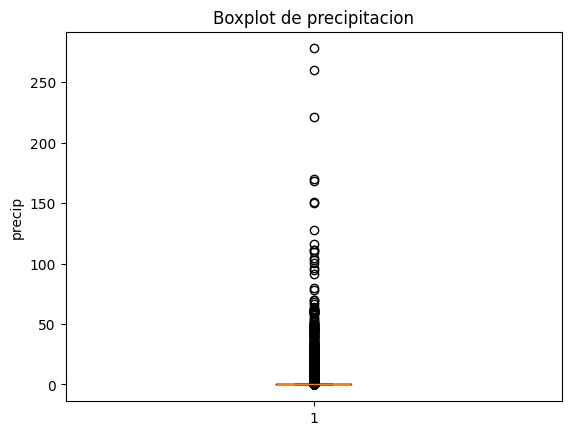

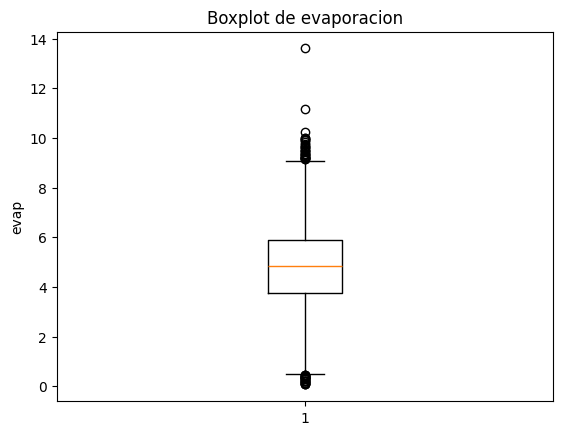

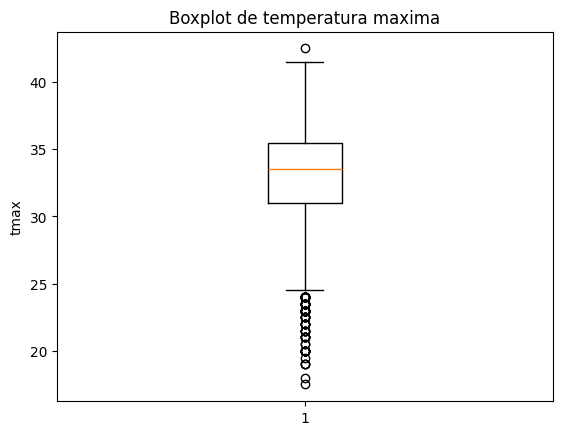

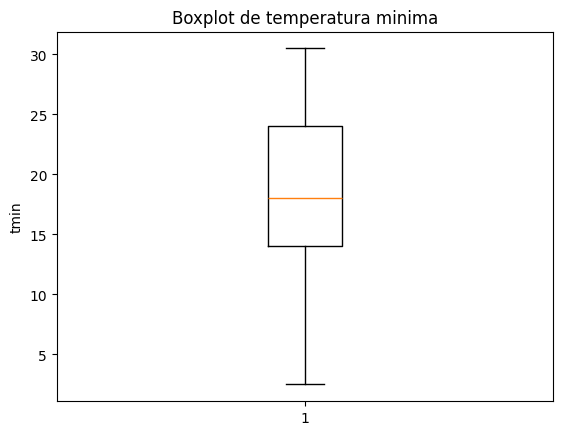

In [42]:
plt.figure()
plt.boxplot(df["precip"])
plt.title("Boxplot de precipitacion")
plt.ylabel("precip")
plt.show()

plt.figure()
plt.boxplot(df["evap"])
plt.title("Boxplot de evaporacion")
plt.ylabel("evap")
plt.show()

plt.figure()
plt.boxplot(df["tmax"])
plt.title("Boxplot de temperatura maxima")
plt.ylabel("tmax")
plt.show()

plt.figure()
plt.boxplot(df["tmin"])
plt.title("Boxplot de temperatura minima")
plt.ylabel("tmin")
plt.show()

### Análisis de los boxplots

**Precipitación:**
La mediana se encuentra muy cerca de cero, lo que indica que la mayoría de los días no se registran lluvias. La caja es pequeña, por lo que el 50% central de los datos está concentrado en valores bajos. Sin embargo, los bigotes son largos y aparecen muchos valores atípicos hacia arriba, correspondientes a días con lluvias intensas. Esto coincide con el sesgo hacia la derecha observado en el histograma y la curva de densidad.

**Evaporación:**
La mediana está cerca del centro de la caja, lo que nos dice que hay una distribución relativamente simétrica. la caja es mediana y los bigotes tienen una longitud similar, aunque existen algunos valores atípicos en ambos extremos relacionados con condiciones climáticas poco comunes. La dispersión es mayor que en las temperaturas, pero menor que en la precipitación.

**Temperatura máxima:**
La caja es amplia debido a los cambios de temperatura entre las distintas estaciones del año. La mediana se encuentra cerca del centro, indicando poca asimetría en la distribución. Los valores atípicos son pocos y representan días con temperaturas más altas o más bajas de lo habitual.

**Temperatura mínima:**
Al igual que en la temperatura máxima, la caja es amplia por las estaciones del año. La mediana está centrada dentro de la caja, lo que refleja una distribución bastante equilibrada. Los valores atípicos son escasos y corresponden seguramente a noches con temperaturas inusualmente frías o cálidas.

### 3. Análisis de tendencias

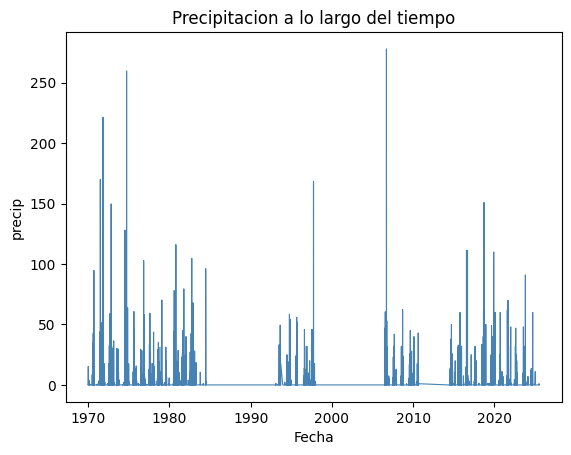

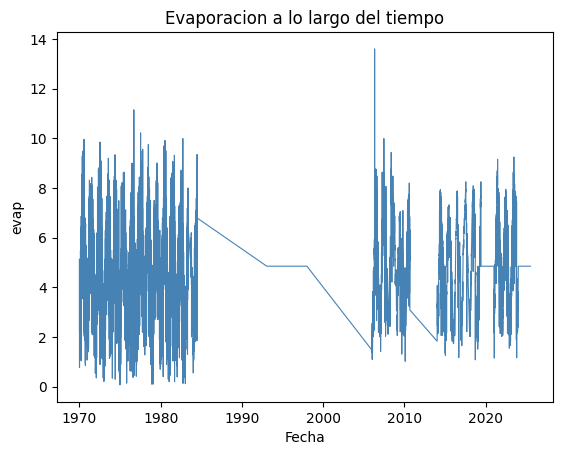

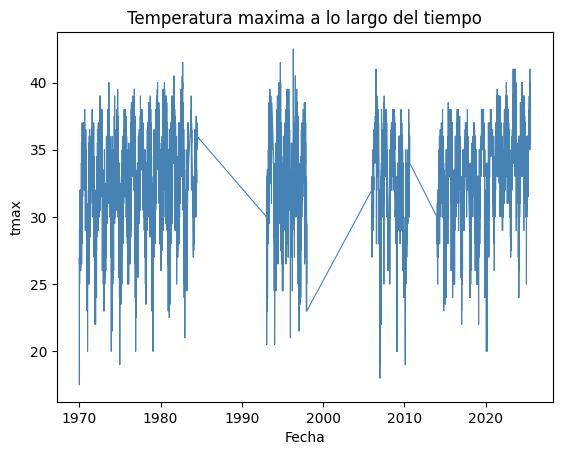

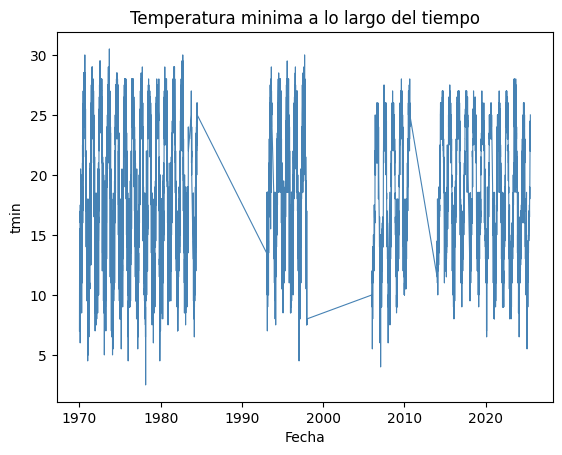

In [ ]:

plt.figure()
plt.plot(df["fecha"], df["precip"], color="steelblue", linewidth=0.8)
plt.title("Precipitacion a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("precip")
plt.show()

plt.figure()
plt.plot(df["fecha"], df["evap"], color="steelblue", linewidth=0.8)
plt.title("Evaporacion a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("evap")
plt.show()

plt.figure()
plt.plot(df["fecha"], df["tmax"], color="steelblue", linewidth=0.8)
plt.title("Temperatura maxima a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("tmax")
plt.show()

plt.figure()
plt.plot(df["fecha"], df["tmin"], color="steelblue", linewidth=0.8)
plt.title("Temperatura minima a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("tmin")
plt.show()

### Análisis de tendencias

**Precipitación:**
La gráfica presenta un comportamiento relativamente estable a lo largo de los años, sin una tendencia clara de aumento o disminución. Se observan picos repetitivos cada año que corresponden a la temporada de lluvias, principalmente entre julio y septiembre. Los valores más altos coinciden con años en los que hubo tormentas tropicales o huracanes que a Sinaloa. Por epocas la precipitación se mantiene cercana a cero, reflejando las epocas en las que no hay lluvia en Culiacán.

**Evaporación:**
La gráfica muestra un comportamiento cíclico por las estaciones No se aprecia una tendencia creciente ni decreciente a lo largo del tiempo, lo que indica que la evaporación se ha mantenido relativamente constante en la región. Esto coincide con la estabilidad observada en las temperaturas.

**Temperatura máxima:**
La gráfica presenta un patrón debido a las estaciones del año, con temperaturas más altas en verano y más bajas en invierno. En general, el comportamiento se mantiene estable, aunque existen pequeñas variaciones entre distintos periodos. Los valores permanecen dentro de un rango similar durante los años analizados, sin cambios drásticos que indiquen un aumento o disminución significativa de la temperatura.

**Temperatura mínima:**
Al igual que la temperatura máxima, la gráfica muestra un patrón de las estaciones del año. La tendencia general es estable y no se observan cambios importantes entre décadas, lo que no dice que las temperaturas nocturnas en Culiacán han permanecido relativamente constantes durante todos estos años.

### 4. Comentarios y conclusiones

**Interpretación global de los resultados estadísticos:**

El análisis de los datos de la estación climatológica 25161 de El Dorado, Culiacán, Sinaloa, que cuenta con más de 50 años de registros diarios, permite observar las características típicas del clima de la región. La precipitación es la variable que presenta más variación, lo cual se nota tanto en su desviación estándar alta como en la forma sesgada de su distribución. En cambio, la evaporación tiene un comportamiento más equilibrado y con menor dispersión. Las temperaturas máxima y mínima son las variables más estables, ya que sus valores cambian de forma más uniforme y siguen claramente el patrón de las estaciones del año.

**Relación entre las gráficas y las medidas numéricas:**

Las gráficas coinciden con los resultados obtenidos en el análisis estadístico. En la precipitación, los histogramas y las curvas de densidad muestran claramente el sesgo hacia la derecha, lo que también se refleja en la diferencia entre la media y la mediana. Los boxplots permiten identificar valores atípicos, especialmente en precipitación y evaporación, relacionados con eventos climáticos poco comunes. Además, las gráficas de líneas muestran patrones repetitivos cada año, lo que indica que las variables mantienen un comportamiento relativamente estable a lo largo del tiempo.

**Explicación de lo que los datos muestran:**

Los datos reflejan el clima característico de Culiacán, con veranos calurosos y lluviosos, e inviernos más secos y templados. La mayor parte de la lluvia ocurre en verano, mientras que durante el resto del año las precipitaciones son bajas. También se observa que las lluvias suelen presentarse en pocos eventos intensos, lo que explica la alta variabilidad en la precipitación diaria. Por otro lado, las temperaturas mantienen un patrón más estable y predecible año con año.

**Posibles implicaciones prácticas o académicas:**

* Este tipo de análisis puede ser útil para la planeación agrícola, ya que ayuda a identificar las épocas con mayor disponibilidad de agua.
* Los registros de temperatura pueden servir como apoyo en estudios relacionados con el cambio climático.
* Los datos de evaporación también son importantes para el manejo de presas y recursos hídricos, ya que permiten estimar pérdidas de agua en embalses como la presa Sanalona.

**Limitaciones del conjunto de datos y posibles mejoras:**

* El dataset contiene varios valores nulos que fueron reemplazados por la media, lo que puede reducir el impacto de algunos eventos extremos reales, ejemplo en las graficas del análisis de tendencias.
* Para mejorar el análisis, lo mejor sería incluir datos de otras estaciones cercanas.
